In [ ]:
import sys
sys.path.insert(0, '/mnt/qh2-nas3/00-model/00-fb/mmseg_dino_agri')

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import colors, cm
from matplotlib.patches import Patch

from mmengine.config import Config
from mmengine.registry import init_default_scope
from mmseg.registry import MODELS
from mmseg.structures import SegDataSample

# 1. 构建模型
cfg = Config.fromfile('/mnt/qh2-nas3/00-model/00-fb/mmseg_dino_agri/configs/dinov3l_m2f_agri.py')
cfg.model.pretrained = None
cfg.model.train_cfg = None
init_default_scope('mmseg')

model = MODELS.build(cfg.model)

# 2. 手动加载 checkpoint（PyTorch 2.6+ 兼容）
ckpt = torch.load(
    '/mnt/qh2-nas3/00-model/00-fb/mmseg_dino_agri/work_dirs/123/20260616_193556/iter_40000.pth',
    map_location='cpu',
    weights_only=False,          # ← 关键！
)

# 3. 加载权重 & 元数据
model.load_state_dict(ckpt['state_dict'], strict=False)
model.dataset_meta = {
    'classes': ['background', 'cropland'],
    'palette': [[0, 0, 0], [34, 139, 34]],
}
model.cfg = cfg
model.to('cuda:0')
model.eval()

print('Model loaded successfully!')

embed dim 1024
interaction_indexes [5, 11, 17, 23]
patch_size 16
Model loaded successfully!


GT crop pixels: 19917 / 65536 (30.39%)


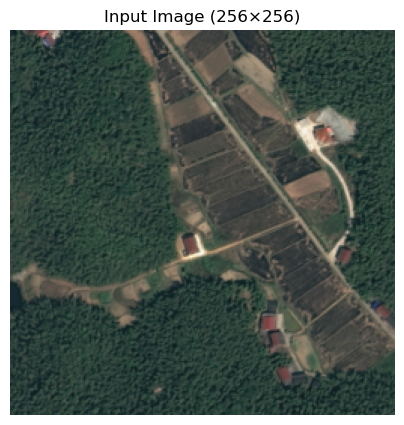

In [ ]:
IMG_SIZE = 256

fn = '20_30_SVDT_JS_JiTingJieDao_2024_08m'

# 遥感原图
IMG_PATH = '/mnt/ht2-nas2/00-model/00-jiangzf/label20000/Segmentation/img_dir/' + fn + '.png'
img_bgr  = cv2.imread(IMG_PATH, cv2.IMREAD_COLOR)
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)

# GT 标注 — 与 LoadCustomRaster 一致: INTER_NEAREST resize, 255→1
GT_PATH  = '/mnt/ht2-nas2/00-model/00-jiangzf/label20000/Segmentation/ann_dir/' + fn + '_mask_seg.png'
gt_raw   = cv2.imread(GT_PATH, cv2.IMREAD_GRAYSCALE)
gt_mask  = cv2.resize(gt_raw, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
gt_mask  = (gt_mask == 255).astype(np.uint8)   # 255 → 1

print(f'GT crop pixels: {gt_mask.sum()} / {IMG_SIZE*IMG_SIZE} '
      f'({gt_mask.sum()/IMG_SIZE/IMG_SIZE*100:.2f}%)')

# matplotlib 预览原图
plt.figure(figsize=(5, 5))
plt.imshow(img_resized)
plt.title('Input Image (256×256)')
plt.axis('off')
plt.show()

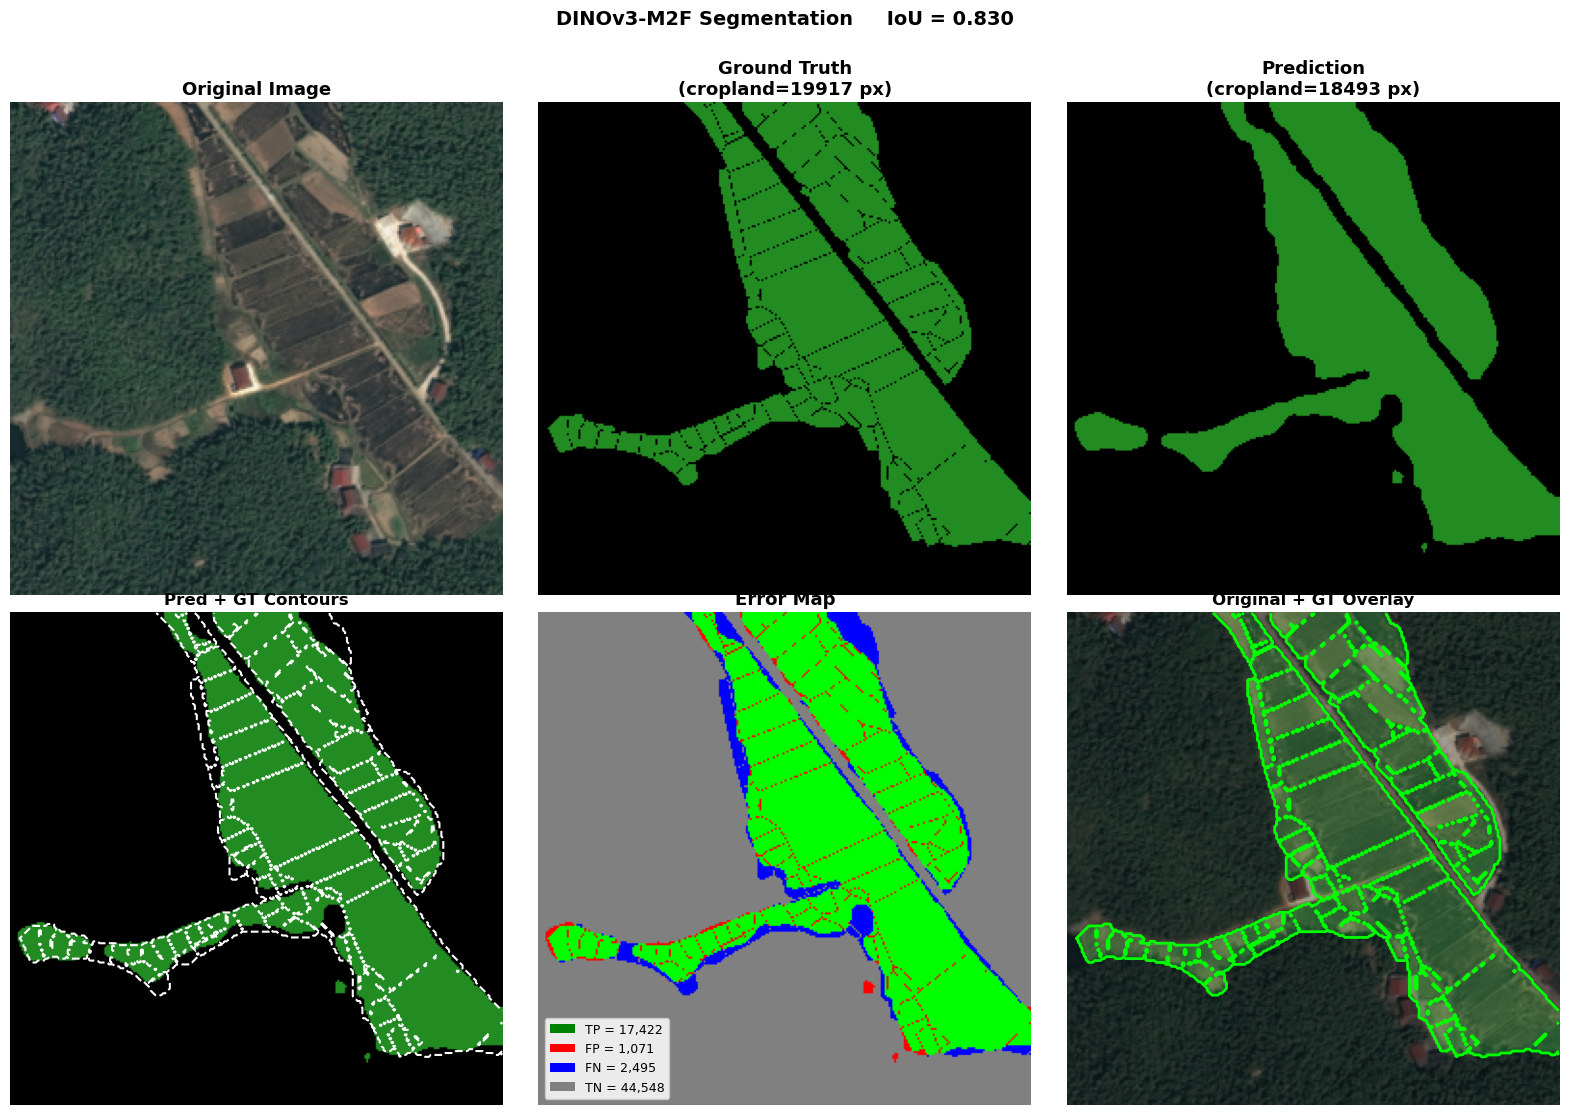

In [12]:
# 3. 推理
# ═══════════════════════════════════════════════════════════════════
tensor = torch.from_numpy(img_resized).float().permute(2, 0, 1).cuda()  # (3,256,256)

data_sample = SegDataSample()
data_sample.set_metainfo({
    'img_shape':       (IMG_SIZE, IMG_SIZE),
    'ori_shape':       (IMG_SIZE, IMG_SIZE),
    'pad_shape':       (IMG_SIZE, IMG_SIZE),
    'scale_factor':    (1.0, 1.0),
    'flip':            False,
    'flip_direction':  None,
})

with torch.no_grad():
    result = model.test_step({
        'inputs':       [tensor],
        'data_samples': [data_sample],
    })

pred_mask = result[0].pred_sem_seg.data.cpu().numpy().squeeze(0)  # (256, 256)

# ═══════════════════════════════════════════════════════════════════
# 4. 可视化 — GT 重叠在预测 mask 上 + 误差图
# ═══════════════════════════════════════════════════════════════════
palette = np.array([[0, 0, 0], [34, 139, 34]], dtype=np.uint8)

# 渲染各 mask 为彩色图
color_gt   = palette[gt_mask]      # GT 颜色 — forestgreen
color_pred = palette[pred_mask]    # 预测颜色 — forestgreen

# 误差分析
tp = (pred_mask == 1) & (gt_mask == 1)   # True Positive  — 预测对农田
fp = (pred_mask == 1) & (gt_mask == 0)   # False Positive — 误判为农田
fn = (pred_mask == 0) & (gt_mask == 1)   # False Negative — 漏判农田
tn = (pred_mask == 0) & (gt_mask == 0)   # True Negative  — 正确判为背景

# 误差着色图 (R=FP, B=FN, G=TP, 灰=TN)
error_map = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
error_map[tp] = [0,   255, 0]    # 绿色: 正确检出农田
error_map[fp] = [255, 0,   0]    # 红色: 过检 (把背景判成农田)
error_map[fn] = [0,   0,   255]  # 蓝色: 漏检 (农田被判成背景)
error_map[tn] = [128, 128, 128]  # 灰色: 正确判为背景

# ── 绘图 ──
fig, axes = plt.subplots(2, 3, figsize=(16, 11))

# Row 0 — 原图 & GT & 预测
axes[0, 0].imshow(img_resized)
axes[0, 0].set_title('Original Image', fontsize=13, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(color_gt)
axes[0, 1].set_title(f'Ground Truth\n(cropland={gt_mask.sum()} px)', fontsize=13, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(color_pred)
axes[0, 2].set_title(f'Prediction\n(cropland={int(pred_mask.sum())} px)', fontsize=13, fontweight='bold')
axes[0, 2].axis('off')

# Row 1 — GT 轮廓叠在预测上 & 误差图 & 叠加原图
axes[1, 0].imshow(color_pred)
# 画出 GT 轮廓 (白色虚线，线宽 1.5)
axes[1, 0].contour(gt_mask, levels=[0.5], colors='white',
                   linewidths=1.5, linestyles='--')
axes[1, 0].set_title('Pred + GT Contours',
                      fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(error_map)
axes[1, 1].set_title('Error Map', fontsize=13, fontweight='bold')
axes[1, 1].axis('off')
# 图例
legend_elements = [
    Patch(facecolor='green',    label=f'TP = {tp.sum():,}'),
    Patch(facecolor='red',      label=f'FP = {fp.sum():,}'),
    Patch(facecolor='blue',     label=f'FN = {fn.sum():,}'),
    Patch(facecolor='gray',     label=f'TN = {tn.sum():,}'),
]
axes[1, 1].legend(handles=legend_elements, loc='lower left',
                  fontsize=9, framealpha=0.85)

axes[1, 2].imshow(img_resized)
# 半透明 GT
axes[1, 2].imshow(color_gt, alpha=0.35)
# GT 轮廓
axes[1, 2].contour(gt_mask, levels=[0.5], colors='#00FF00',
                   linewidths=2.0, linestyles='-')
axes[1, 2].set_title('Original + GT Overlay',
                      fontsize=12, fontweight='bold')
axes[1, 2].axis('off')

# 全局标题
iou = tp.sum() / (tp.sum() + fp.sum() + fn.sum() + 1e-8)
fig.suptitle(f'DINOv3-M2F Segmentation     IoU = {iou:.3f}',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

In [ ]:
a = 1 
b = 2 
c = a+b
print(c)